In [19]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

In [2]:
df = pd.read_csv("/imbalanced_data.csv")

df = df[['tweet', 'label']]
df.dropna(inplace=True)

print(df.head())

                                               tweet  label
0   @user when a father is dysfunctional and is s...      0
1  @user @user thanks for #lyft credit i can't us...      0
2                                bihday your majesty      0
3  #model   i love u take with u all the time in ...      0
4             factsguide: society now    #motivation      0


In [3]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'@\w+', '', text)  # remove mentions
    text = re.sub(r'http\S+|www\S+', '', text)  # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)  # remove special chars & numbers
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
    return text

df['tweet'] = df['tweet'].apply(clean_text)

In [4]:
X = df['tweet']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [5]:
vocab_size = 5000
max_len = 25

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

In [17]:
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_length=max_len),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.9320 - loss: 0.2460 - val_accuracy: 0.9359 - val_loss: 0.2398
Epoch 2/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.9401 - loss: 0.2055 - val_accuracy: 0.9382 - val_loss: 0.2315
Epoch 3/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9471 - loss: 0.1720 - val_accuracy: 0.9413 - val_loss: 0.2191
Epoch 4/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9545 - loss: 0.1407 - val_accuracy: 0.9445 - val_loss: 0.2242
Epoch 5/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9559 - loss: 0.1367 - val_accuracy: 0.9210 - val_loss: 0.2599
Epoch 6/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9718 - loss: 0.0932 - val_accuracy: 0.9128 - val_loss: 0.2695
Epoch 7/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9792 - loss: 0.0680 - val_accuracy: 0.9230 - val_loss: 0.2775
Epoch 8/10
720/720 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9856 - loss: 0.0479 - val_ac

In [15]:
import matplotlib.pyplot as plt

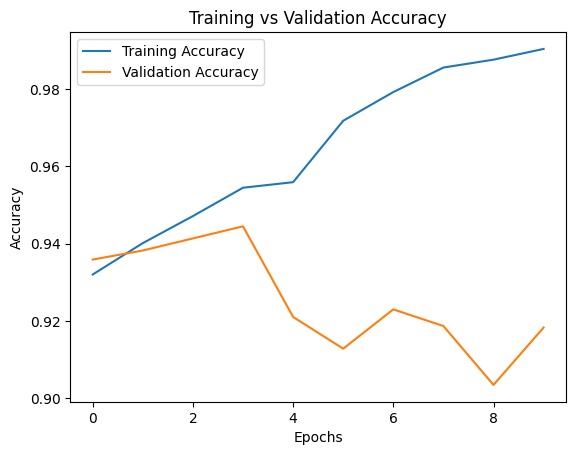

In [20]:
# Plot Accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.show()

In [21]:
y_pred = (model.predict(X_test_pad) > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy: 0.9269513530423901
Confusion Matrix:
 [[5719  226]
 [ 241  207]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96      5945
           1       0.48      0.46      0.47       448

    accuracy                           0.93      6393
   macro avg       0.72      0.71      0.72      6393
weighted avg       0.93      0.93      0.93      6393

